<a href="https://colab.research.google.com/github/corrielynnyuill-debug/AIProject_NLP-CLY/blob/main/AIProject_Part5_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

18846 documents
20 categories
(18846, 5000)
(18846, 5000)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.2 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
(5000, 50)
Inertia:  17775.59335052283
Cluster 0: blessed | filled | feels | fees | feet | fell | fellow | felt | female | fewer
Cluster 1: just | like | good | dont | think | new | know | time | game | im
Cluster 2: tiff | gif | file | formats | image | spec | files | format | convert | bmp
Cluster 3: bike | ride | dod | bikes | riding | just | like | im | motorcycle | miles
Cluster 4: people | god | dont | think | just | like | say | know | believe | government
Cluster 5: computer | measure | stand | voice | sensor | offering | neutral | involves | victims | arm
Cluster 6: thanks | windows | email | know | does | file | use | card | im | program
Cluster 7: subscribe | mailing | list | quit | honda | located | israel | david | want | feelings
Cluster 8: joke | sigh | a

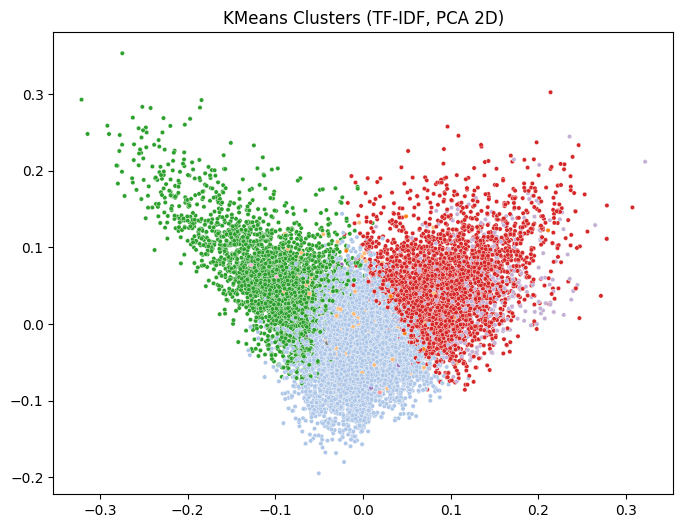

In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = newsgroups.data
labels = newsgroups.target
target_names = newsgroups.target_names

print(len(texts), 'documents')
print(len(target_names), 'categories')

# Text Preprocessing
import re
from sklearn.feature_extraction import text

custom_stopwords = list(text.ENGLISH_STOP_WORDS)

def simple_preprocessor(doc):
    doc = doc.lower()
    doc = re.sub(r'[^a-z\s]', '', doc)
    doc = re.sub(r'\s+', ' ', doc).strip()
    return doc

# Bag of Words
bow_vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    preprocessor=simple_preprocessor,
    max_features=5000
    )
X_bow = bow_vectorizer.fit_transform(texts)
print(X_bow.shape)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=simple_preprocessor,
    stop_words=custom_stopwords,
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(texts)
print(X_tfidf.shape)

# Simple word embeddings
!pip install gensim
from gensim.models import KeyedVectors
from gensim.downloader import load as gensim_load

# Download a small pre-trained embedding
w2v = gensim_load('glove-wiki-gigaword-50')

def doc_to_vec(doc, model=w2v):
  tokens = simple_preprocessor(doc).split()
  vecs = [model[token] for token in tokens if token in model]
  if not vecs:
    return np.zeros(model.vector_size)
  return np.mean(vecs, axis=0)

# Build embedding matrix
n_docs = 5000
embeddings = np.vstack([doc_to_vec(t) for t in texts[:n_docs]])
print(embeddings.shape)

# K-Means Clustering
k = 20
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_tfidf)

print('Inertia: ', kmeans.inertia_)

# Inspect clusters
def top_terms_per_cluster(model, vectorizer, n_terms=10):
  terms = np.array(vectorizer.get_feature_names_out())
  centers = model.cluster_centers_
  for i in range(model.n_clusters):
    top_idx = centers[i].argsort()[::-1][:n_terms]
    print(f'Cluster {i}: {' | '.join(terms[top_idx])}')

top_terms_per_cluster(kmeans, tfidf_vectorizer)

# Hierarchical clustering
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
agg_labels = agg.fit_predict(X_tfidf.toarray()[:2000])

# Model Evaluation
# Silohouette score
sil_kmeans = silhouette_score(X_tfidf, kmeans_labels)
print(f'K-Means Silhouette Score: {sil_kmeans}')

# Predict clusters for new docs
new_docs = [
    'The graphics card onmy computer is not working properly.',
    'The team played an amazing hockey game last night.'
]

new_X = tfidf_vectorizer.transform(new_docs)
new_labels = kmeans.predict(new_X)

for doc, label in zip(new_docs, new_labels):
  print('Doc', doc)
  print('Cluster', label)
  print()

pd.crosstab(labels, kmeans_labels)

# Visualize
X_tfidf_dense = X_tfidf.toarray()
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_tfidf_dense)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=kmeans_labels,
    palette='tab20',
    legend=False,
    s=10
)
plt.title('KMeans Clusters (TF-IDF, PCA 2D)')
plt.show()
